# Dipole Moment Code Testing

This notebook explores whether the dipole moment surfaces (DMS) obtained from fitting code and calculations are valid for use. 

## 1. Original 1D Dipoles
We first upload the original 1D dipole moment values from MOLPRO calculations. These are extracted from the excel 1d_dms_cleaned.xlsx file. 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
# Load the Excel file
file_path = "1d_dms_cleaned.xlsx"  
xls = pd.ExcelFile(file_path)

# Sheet names in order (excluding 'Sheet1' and 'Sheet2')
sheets = ["rpo1", "rpo2", "roh", "aopo", "apoh", "tau"]

# Iterate over sheets and extract the required columns
for i, sheet in enumerate(sheets):
    df = pd.read_excel(xls, sheet_name=sheet)
    
    # Determine columns to extract (1-based index needs to be converted to 0-based)
    cols = [i + 1, 8, 9, 10]  # Adjusted based on sheet position
    selected_columns = df.iloc[:, [c - 1 for c in cols]]
    
    # Convert each column to a separate NumPy array
    arrays = [selected_columns.iloc[:, j].to_numpy() for j in range(selected_columns.shape[1])]
    
    # Assign arrays to variables dynamically
    col_names = ["", "dipx", "dipy", "dipz"]
    for j, arr in enumerate(arrays):
        globals()[f"{sheet}_{col_names[j]}"] = arr

#check examples
print(aopo_[100])  
print(aopo_dipy[100])
#print(tau_dipz)

#remove erroneous result 
aopo_ = np.delete(aopo_, 100)
aopo_dipx = np.delete(aopo_dipx, 100)
aopo_dipy = np.delete(aopo_dipy, 100)
aopo_dipz = np.delete(aopo_dipz, 100)

176
20.573980483957


The 1D dipole moment surface can be plotted for each directional component and each of the 6 coordinates. Note there is no x-component dipole for all coordinates except torsion as the planar molecules sit on the yz-axis. 

In [9]:
coords = [rpo1_, rpo2_, roh_, aopo_, apoh_, tau_]
dipx = [rpo1_dipx, rpo2_dipx, roh_dipx, aopo_dipx, apoh_dipx, tau_dipx]
dipy = [rpo1_dipy, rpo2_dipy, roh_dipy, aopo_dipy, apoh_dipy, tau_dipy]
dipz = [rpo1_dipz, rpo2_dipz, roh_dipz, aopo_dipz, apoh_dipz, tau_dipz]
x_units = ['Å','Å','Å', '°', '°', '°']
figure_name = ['dms_rpo1', 'dms_rpo2', 'dms_roh', 'dms_aopo', 'dms_apoh', 'dms_tau']

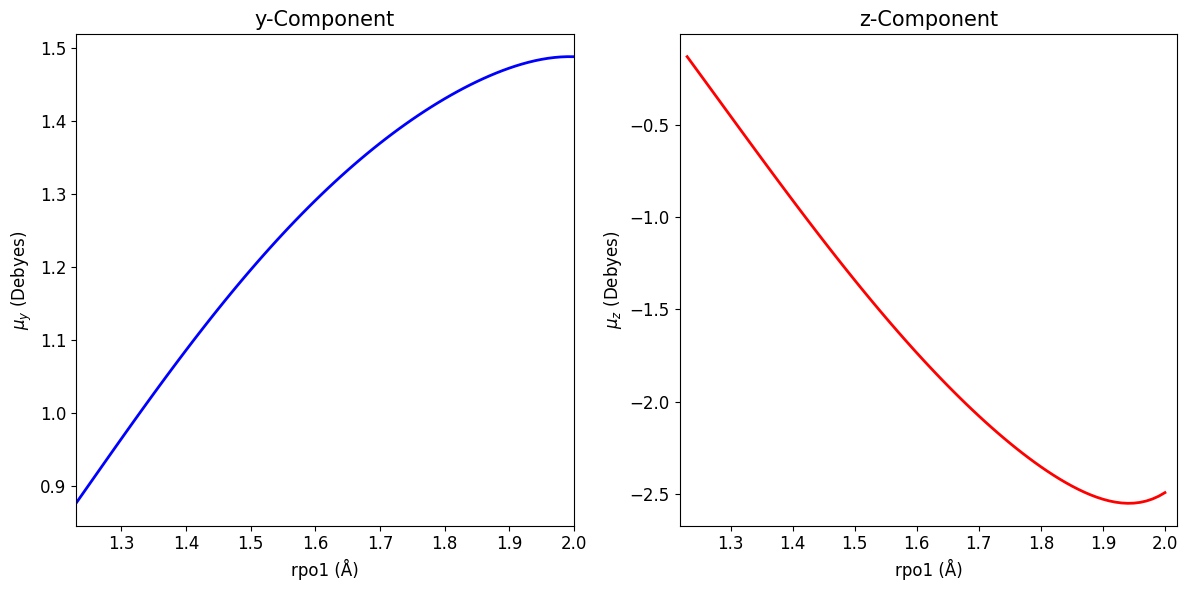

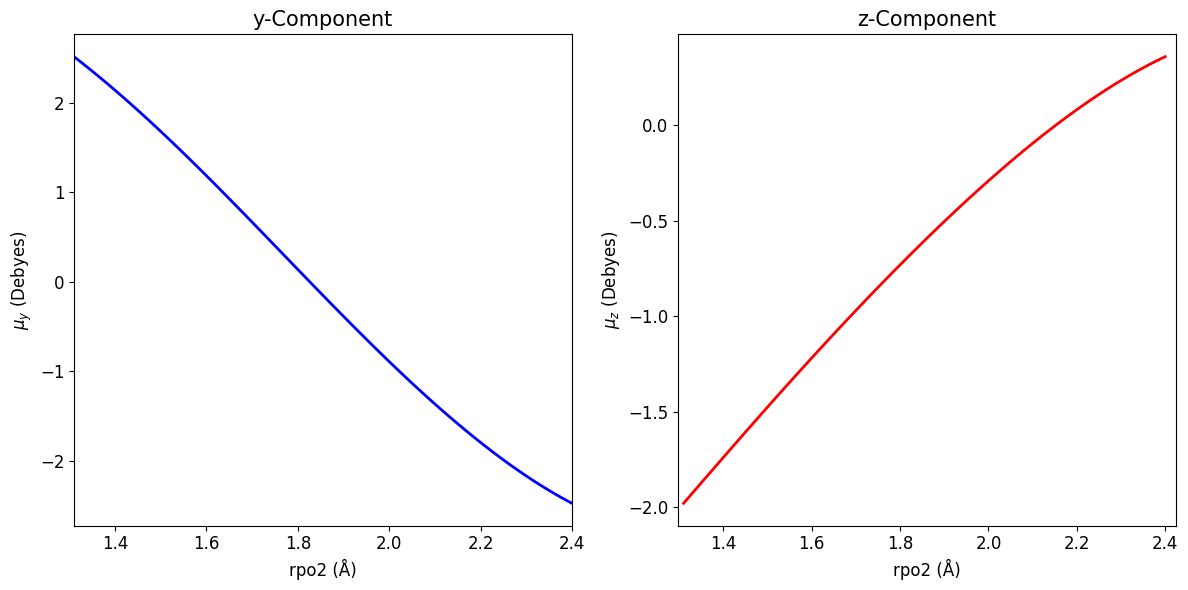

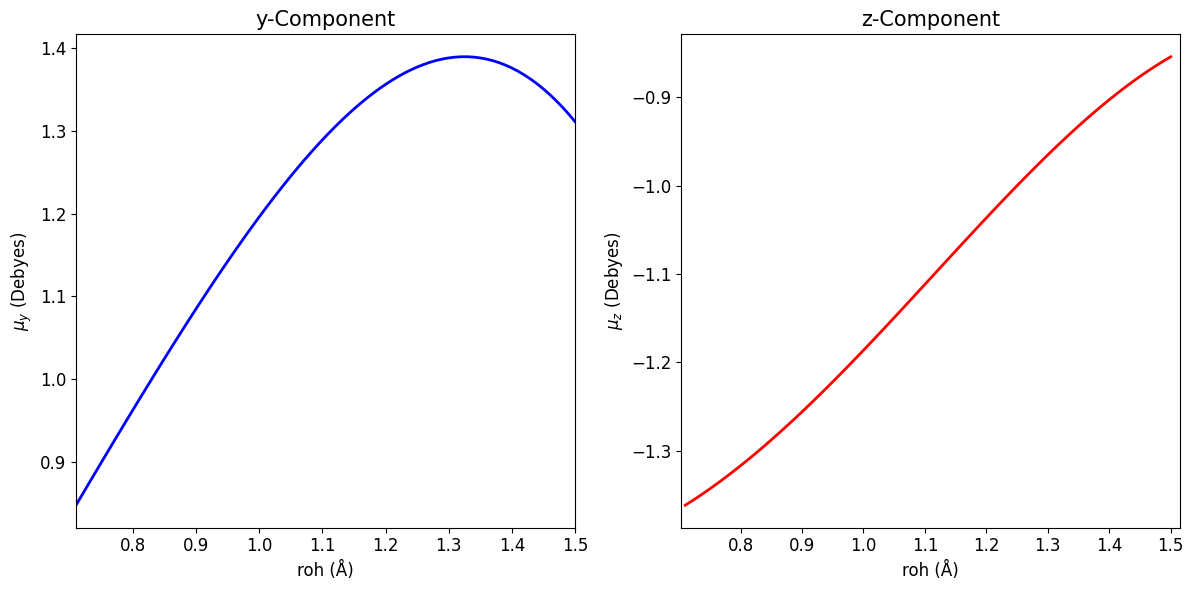

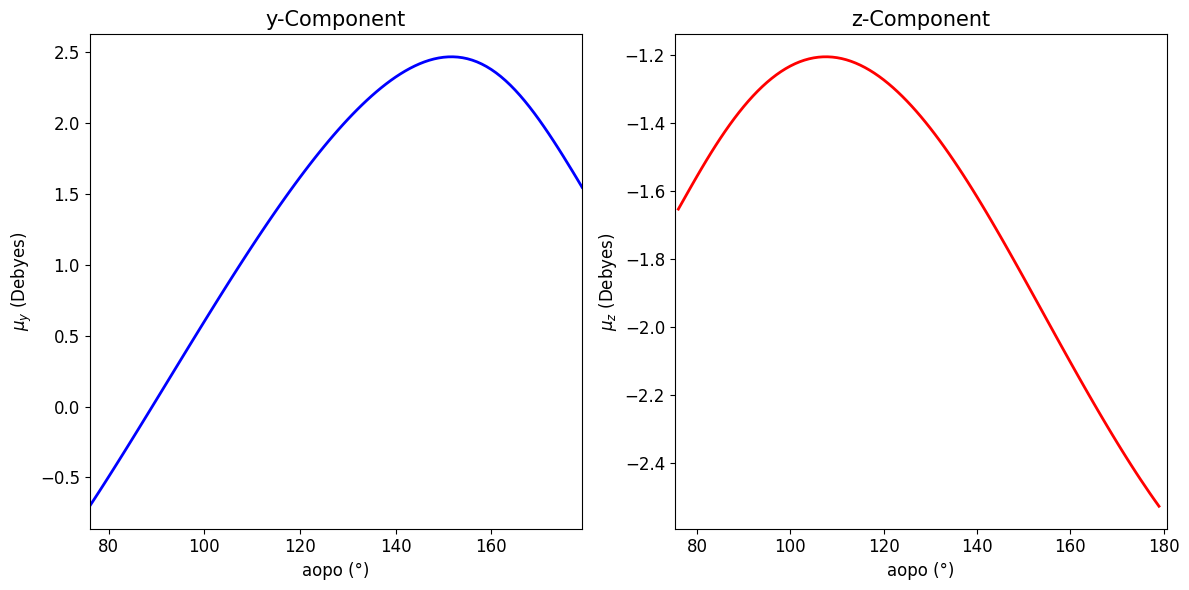

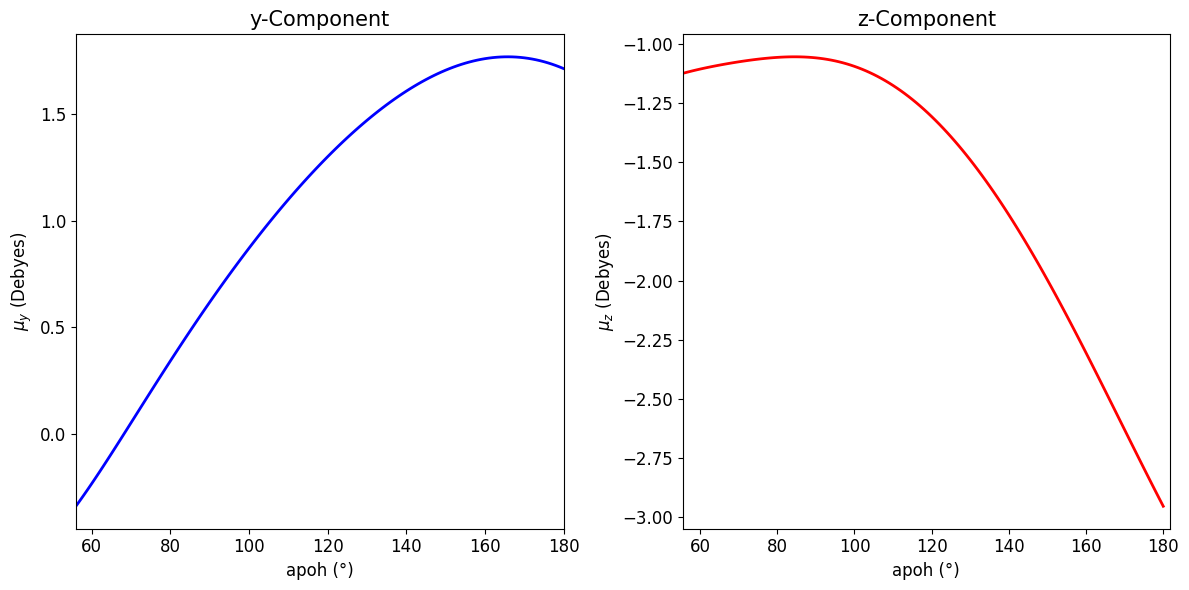

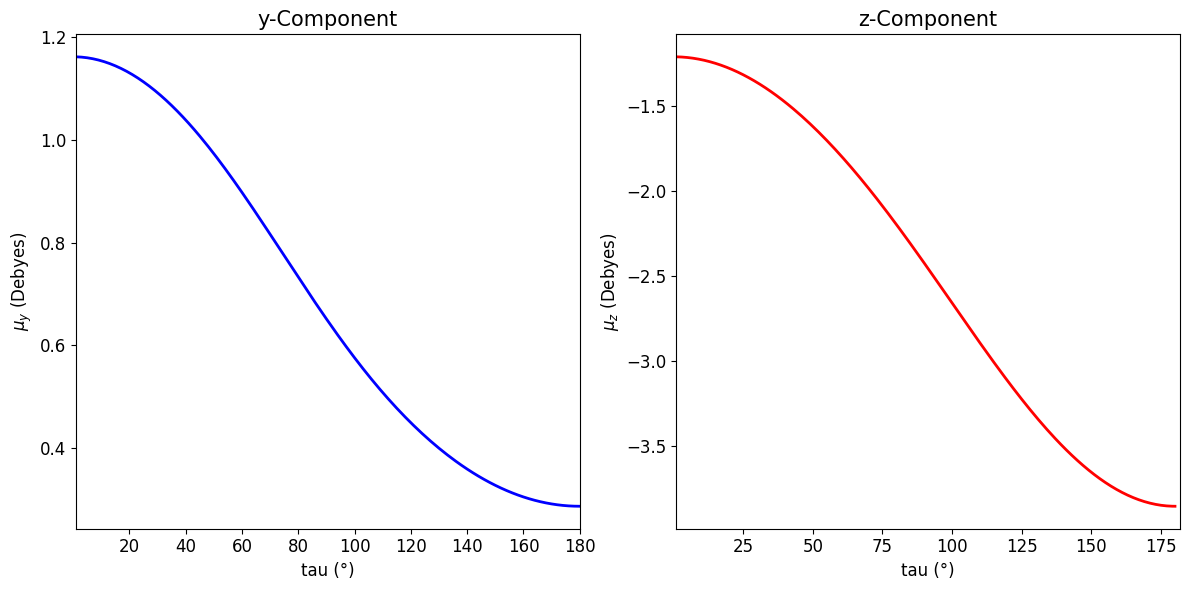

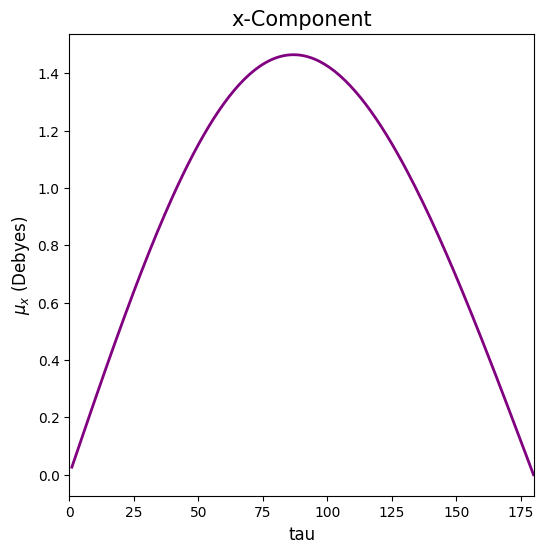

In [10]:
for i in range(len(coords)):
    
    # Create the figure
    fig = plt.figure(figsize=(12, 6))  # Adjust size as needed

    # Add subplots (1 row, 2 columns)
    ax1 = fig.add_subplot(1, 2, 1)  # First subplot
    ax2 = fig.add_subplot(1, 2, 2)  # Second subplot

    # plot two columns
    ax1.plot(coords[i], dipy[i], color='blue', linewidth=2)
    ax1.set_title("y-Component", fontsize=15)
    ax1.set_xlabel(f'{sheets[i]} ({x_units[i]})', fontsize=12)
    ax1.set_ylabel(f'$μ_y$ (Debyes)', fontsize=12)
    ax1.set_xlim(np.min(coords[i]), np.max(coords[i]))
    ax1.tick_params(axis='both', labelsize=12)

    ax2.plot(coords[i], dipz[i], color='red', linewidth=2)
    ax2.set_title("z-Component", fontsize=15)
    ax2.set_xlabel(f'{sheets[i]} ({x_units[i]})', fontsize=12)
    ax2.set_ylabel(f'$μ_z$ (Debyes)', fontsize=12)
    ax2.set_xlim(0.99*np.min(coords[i]), 1.01*np.max(coords[i]))
    ax2.tick_params(axis='both', labelsize=12)

    plt.tight_layout()
    plt.show()
    
fig = plt.figure(figsize=(6, 6))
plt.title('x-Component', fontsize=15)
plt.plot(coords[5], dipx[5], color='purple', linewidth=2)
plt.xlabel('tau', fontsize=12)
plt.ylabel(f'$μ_x$ (Debyes)', fontsize=12)
plt.xlim(0, 180.3);

## 2. Coordinate Transformation 
We now perform a change of basis to a desired frame which is used for rovibrational energy calculations as well as the DMS fit itself. We should expect that the fitting code produces the same 1D surface as seen by the plots produced after the basis transformation has been implemented. The basis change will be a 3D rotation.

Basis vectors are developed from positions of atoms in the original frame. The position coordinates are extracted from the dms1d.txt file.

In [11]:
#configuration H-O-P-O
#trove labels H - atom4, O - atom 2, P - atom 1, O - atom 3
#MOLPRO labels H - atom4, O - atom 3, P - atom 1, O - atom 2
M_atom1, M_atom2, M_atom3, M_atom4 = None, None, None, None #molpro 
T_atom1, T_atom2, T_atom3, T_atom4 = None, None, None, None #trove
atoms = [None, None, None, None]

#open file and get cartesian coordinates 
with open('dms1d.txt', 'r') as file:
    line = file.readline()
    line_split = line.split()
    
    for j in range(4):
        atoms[j] = line_split[3*j:3*j+3]
        for i in range(3):
            atoms[j][i] = float(atoms[j][i])
        atoms[j] = np.array(atoms[j])

for j in range(4):
    exec(f'M_atom{j+1} = atoms[{j}]')
    
#get trove labeling of atomic coordinates (swap 2 and 3)
T_atom1, T_atom2, T_atom3, T_atom4 = M_atom1, M_atom3, M_atom2, M_atom4

#first basis vector (z-axis in TROVE frame)
v = T_atom2 - T_atom1 
e3 = v / np.linalg.norm(v) #basis vec

#2nd basis vector (y-axis in TROVE frame)
u = T_atom3 - T_atom1
w = np.cross(v, u)
e2 = w / np.linalg.norm(w)

#3rd basis vector (x-axis in TROVE frame)
e1 = np.cross(e2, e3)

print(f'x unit vector: {e1}')
print(f'y unit vector: {e2}')
print(f'z unit vector: {e3}')

print()
R_mat = np.array([e1, e2, e3])
print(f'Rotation Matrix: \n{R_mat}')

x unit vector: [0.         0.35175339 0.9360927 ]
y unit vector: [ 1. -0.  0.]
z unit vector: [ 0.          0.9360927  -0.35175339]

Rotation Matrix: 
[[ 0.          0.35175339  0.9360927 ]
 [ 1.         -0.          0.        ]
 [ 0.          0.9360927  -0.35175339]]


We now apply the rotation to the dipole vectors

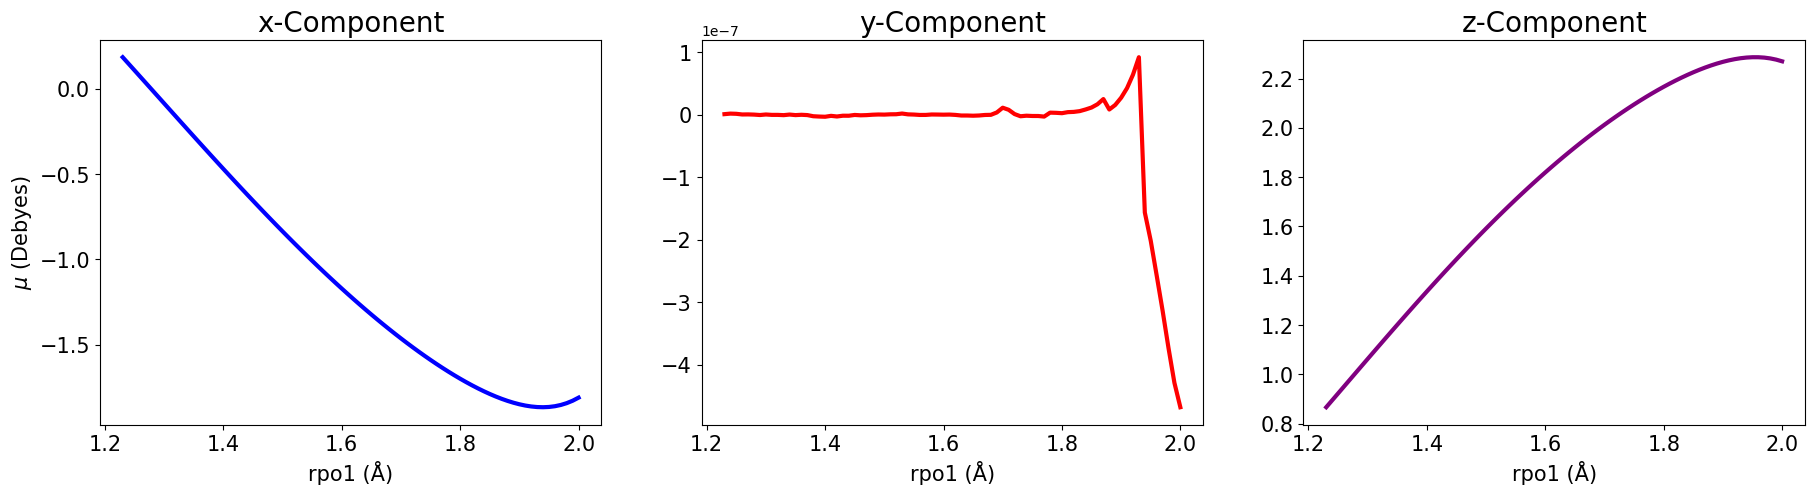

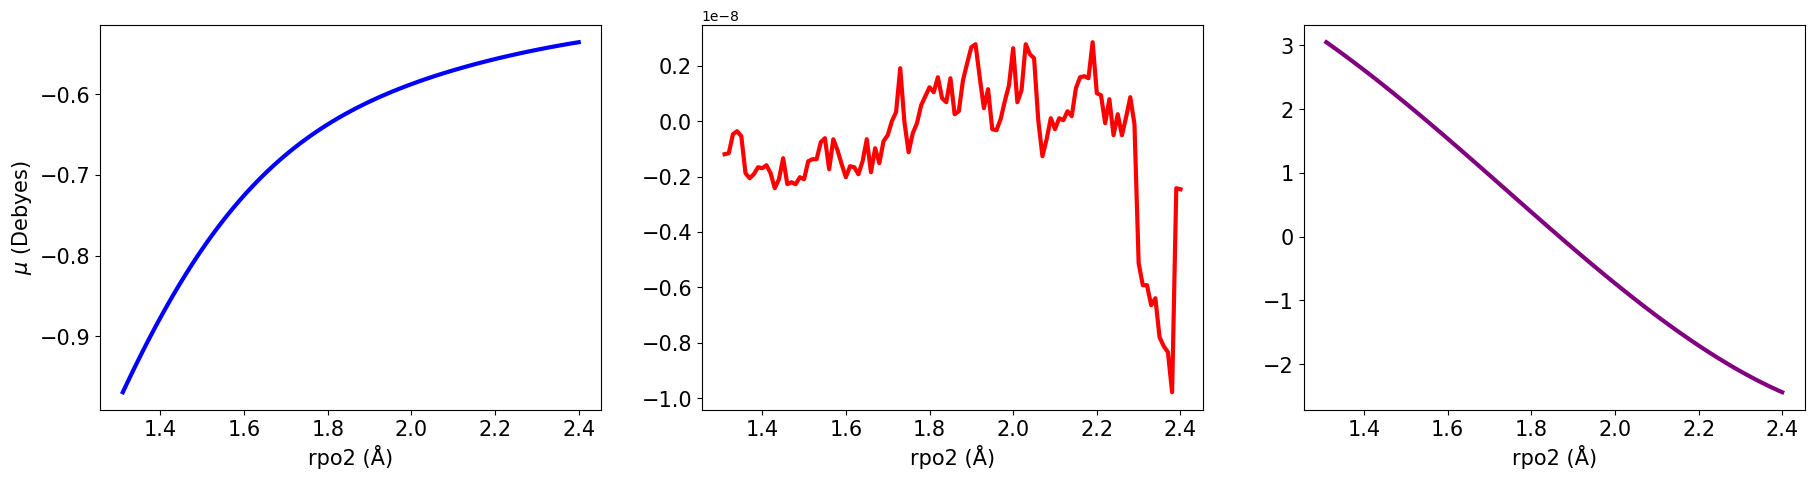

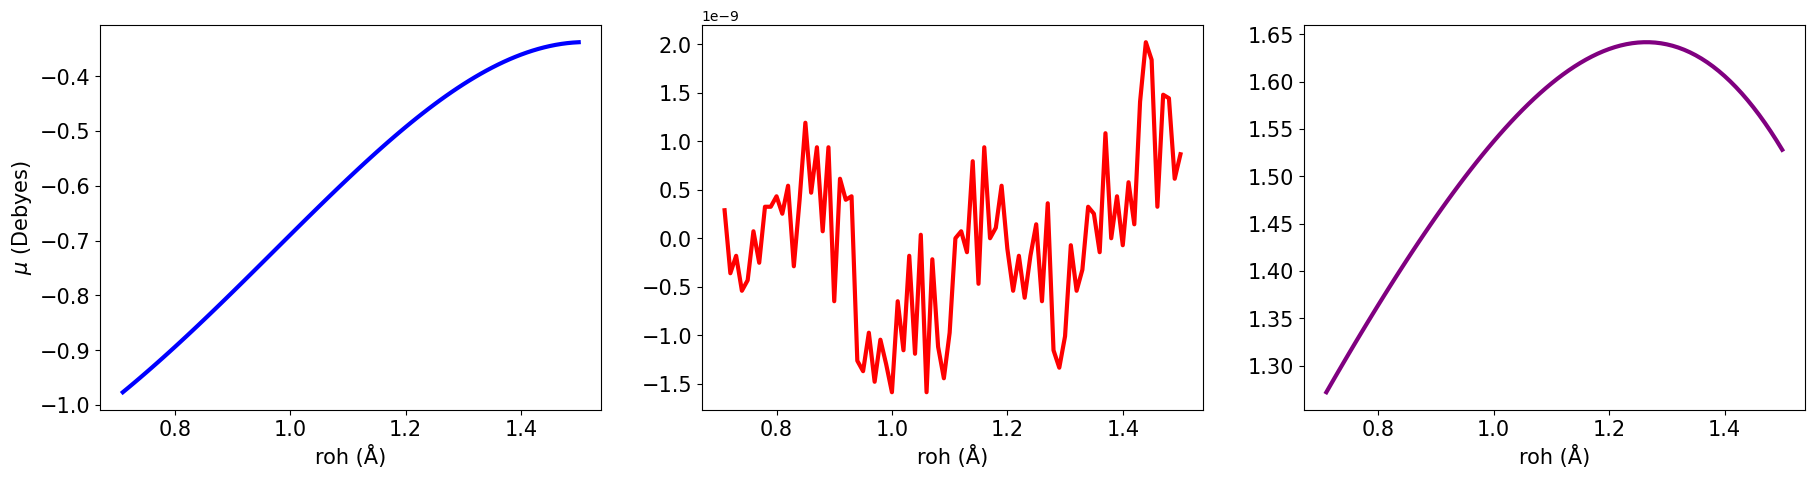

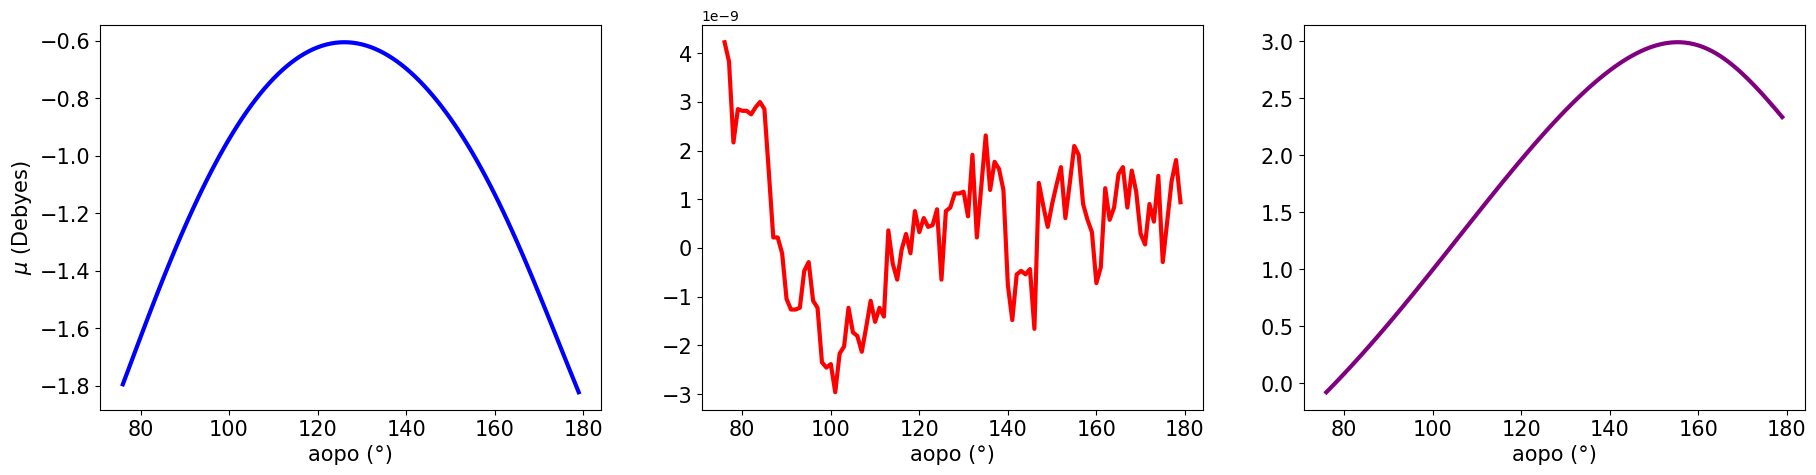

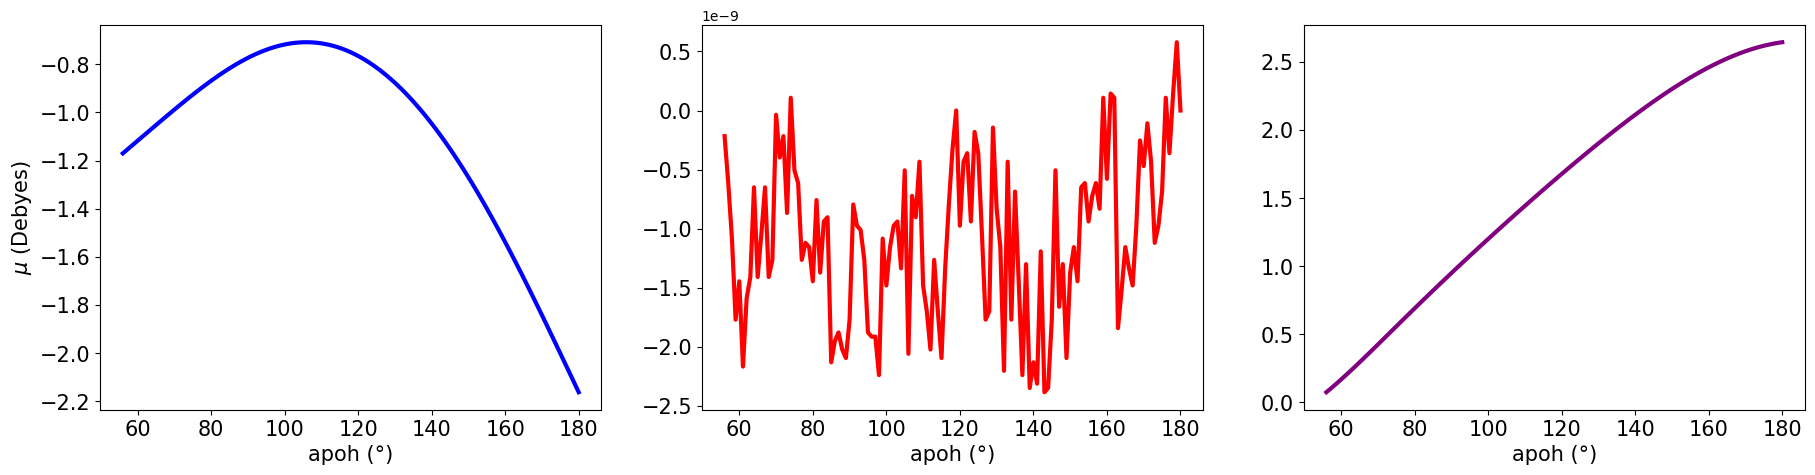

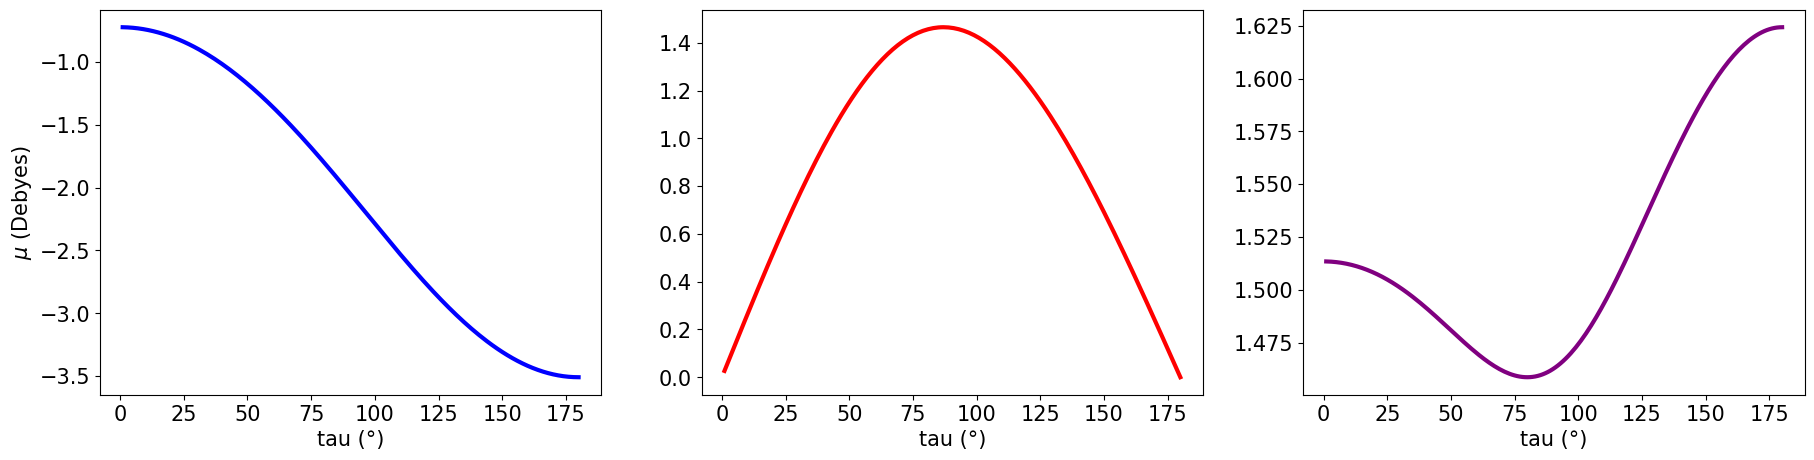

In [12]:
titles = ["x-Component","y-Component","z-Component"]
line_color = ['blue', 'red', 'purple']

#loop over each internal coordinate
for j in range(6):
    #compute rotated dipole elements
    dipole_mat = [dipx[j], dipy[j], dipz[j]]
    rotated_dipole_mat = R_mat @ dipole_mat
    
    #separate into components
    rotated_dipx = rotated_dipole_mat[0, :]
    rotated_dipy = rotated_dipole_mat[1, :]
    rotated_dipz = rotated_dipole_mat[2, :]
    r_dip = [rotated_dipx, rotated_dipy, rotated_dipz]
    
    #plot each component for each coordinate
    fig, ax = plt.subplots(1,3, figsize=(22,5))
    for k in range(3):
        ax[k].plot(coords[j], r_dip[k], lw=3, color=line_color[k])
        ax[k].set_xlabel(f'{sheets[j]} ({x_units[j]})', fontsize=15)
        ax[k].tick_params(labelsize=15)
        if k == 0:
            ax[k].set_ylabel(f'$μ$ (Debyes)', fontsize=15)
        if j == 0:
            ax[k].set_title(titles[k], fontsize=20)

These are the surfaces we expect the fitting code to compute in the 1D case. DMS fits are then fit to these values rather than the raw original values seen. Note the y-component is now the 0-dipole direction when the molecule is planar.

# 3. DMS Fitting Testing

We now compare this to the analytic surfaces which are obtained from fitting to the dipole moment values. The parameters of the fit are found in the .res files. We import a module (compute_dms.py) to extract parameters in the .res files and build the DMS functions. 

In [13]:
import compute_dms as cdms

### 3.1 1D Fitting (Test Case)

As a test of the code, we first test the 1D fitting of varying the torsional angle obtained. We should be able to replicate the transformed tau dipole values as plotted above.

In [14]:
test_equilibriums = [1.604156, 1.468327, 0.968308, 110.594598, 112.98606, 0]

tau_test_1D_geometry = np.zeros((100, 6))
for j in range(5):
    tau_test_1D_geometry[:, j] = test_equilibriums[j]
tau_test_1D_geometry[:, 5] = np.linspace(0,180,100)
tau_test = tau_test_1D_geometry[:, 5]

x1_param, y1_param, z1_param, x1_pow, y1_pow, z1_pow = cdms.get_coeffs_powers('1d_dms_tau.res')
r_eq_1d = cdms.get_non_linear_p('1d_dms_tau.res')

x1_dms = cdms.get_dms(x1_param, r_eq_1d, x1_pow, 'x')
y1_dms = cdms.get_dms(y1_param, r_eq_1d, y1_pow, 'y')
z1_dms = cdms.get_dms(z1_param, r_eq_1d, z1_pow, 'z')

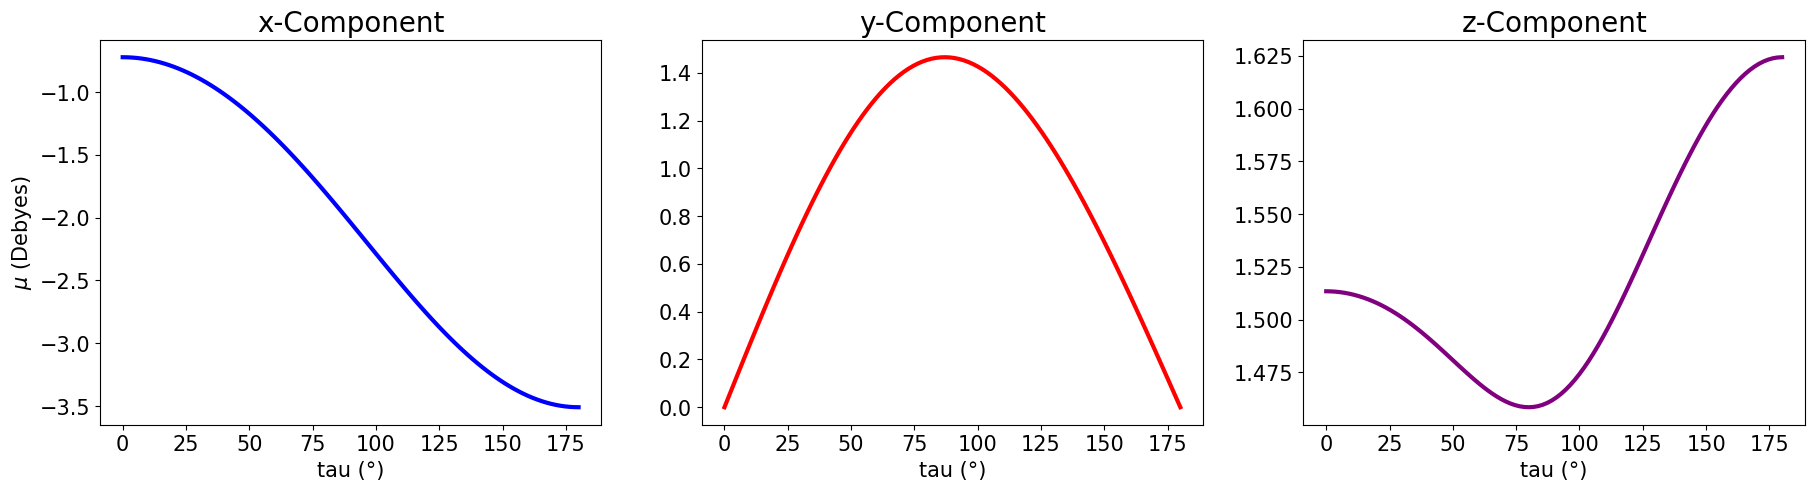

In [15]:
dms_1d = [x1_dms, y1_dms, z1_dms]
fig, ax = plt.subplots(1,3, figsize=(22,5))
for j in range(3):
    ax[j].plot(tau_test, dms_1d[j](tau_test_1D_geometry), lw=3, color=line_color[j])
    ax[j].set_xlabel(f'{sheets[5]} ({x_units[5]})', fontsize=15)
    ax[j].tick_params(labelsize=15)
    ax[j].set_title(titles[j], fontsize=20)
    
ax[0].set_ylabel(f'$μ$ (Debyes)', fontsize=15);

The graph of the coordinate transformed dipole moment points is reconstructed, so both the 1D dipole fit and coordinate transformation of the fortran routine appear correct.

## 4. 6D Case
We use the parameters of the full 6D DMS to generate 1D projections in order to recreate the 1D plots. Given a good fit, we should recreate the 1D plots of the rotated dipole moments. We use parameters from the '6d_dms_04_5.res' file.

In [16]:
x_param, y_param, z_param, x_pow, y_pow, z_pow = cdms.get_coeffs_powers('6d_dms_04_5.res')
r_eq = cdms.get_non_linear_p('6d_dms_04_5.res')

x_dms = cdms.get_dms(x_param, r_eq, x_pow, 'x')
y_dms = cdms.get_dms(y_param, r_eq, y_pow, 'y')
z_dms = cdms.get_dms(z_param, r_eq, z_pow, 'z')

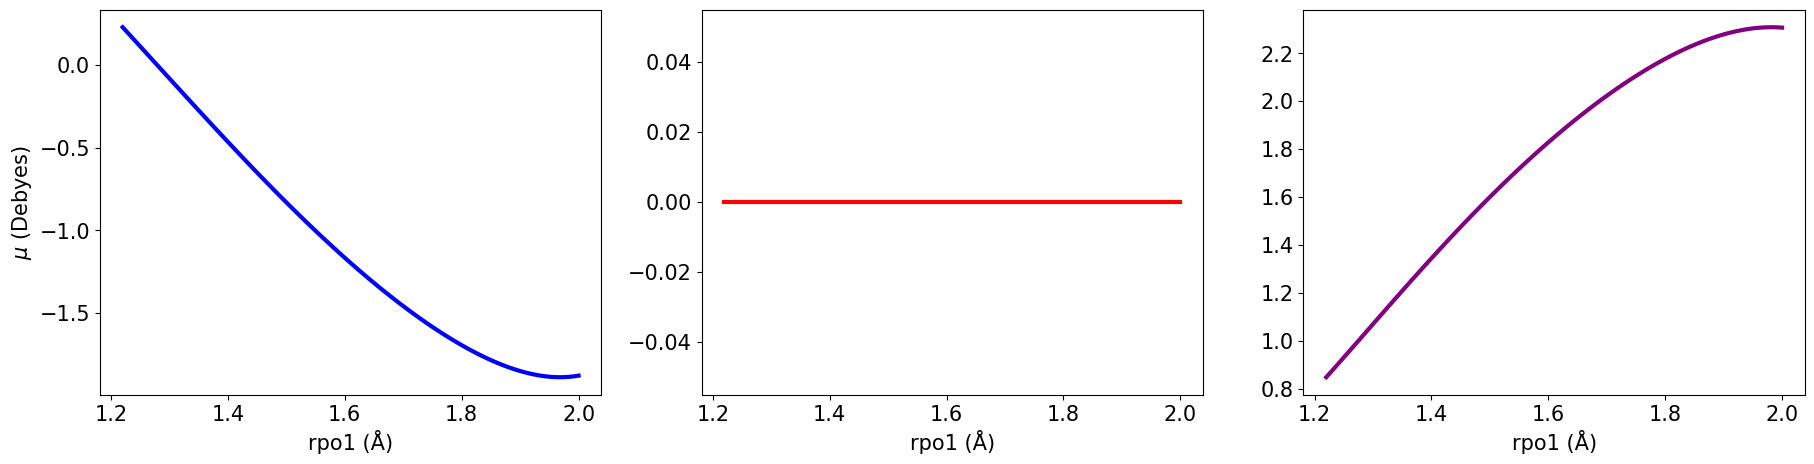

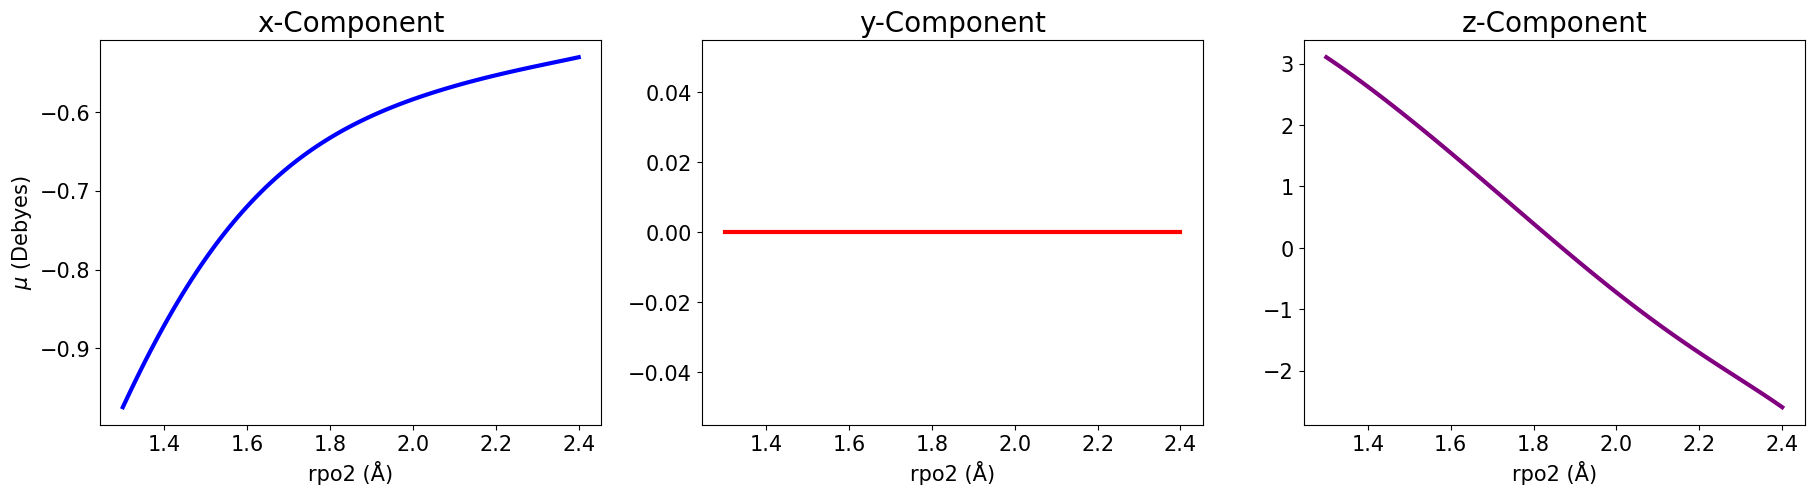

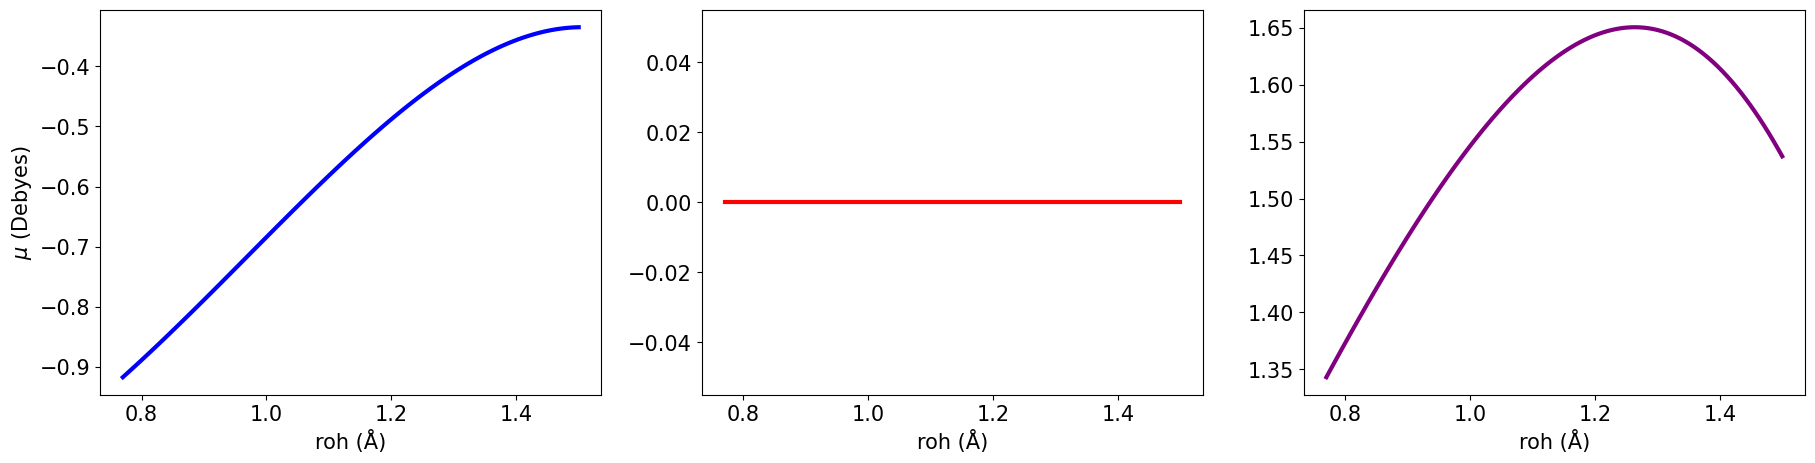

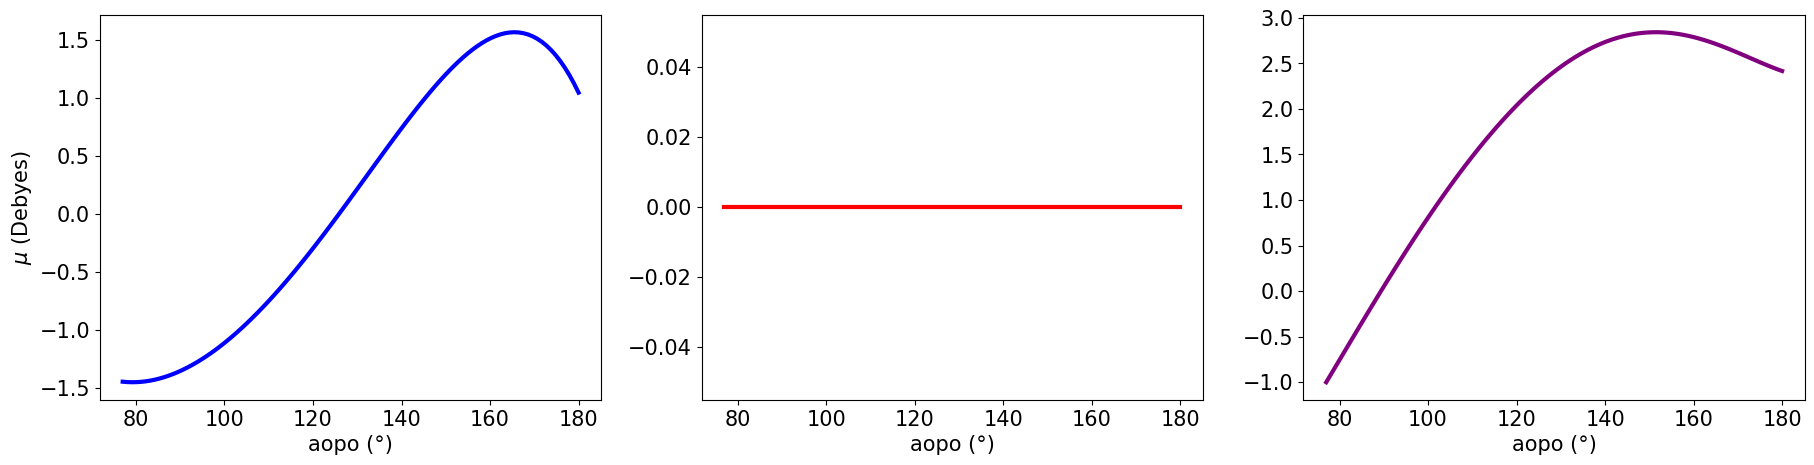

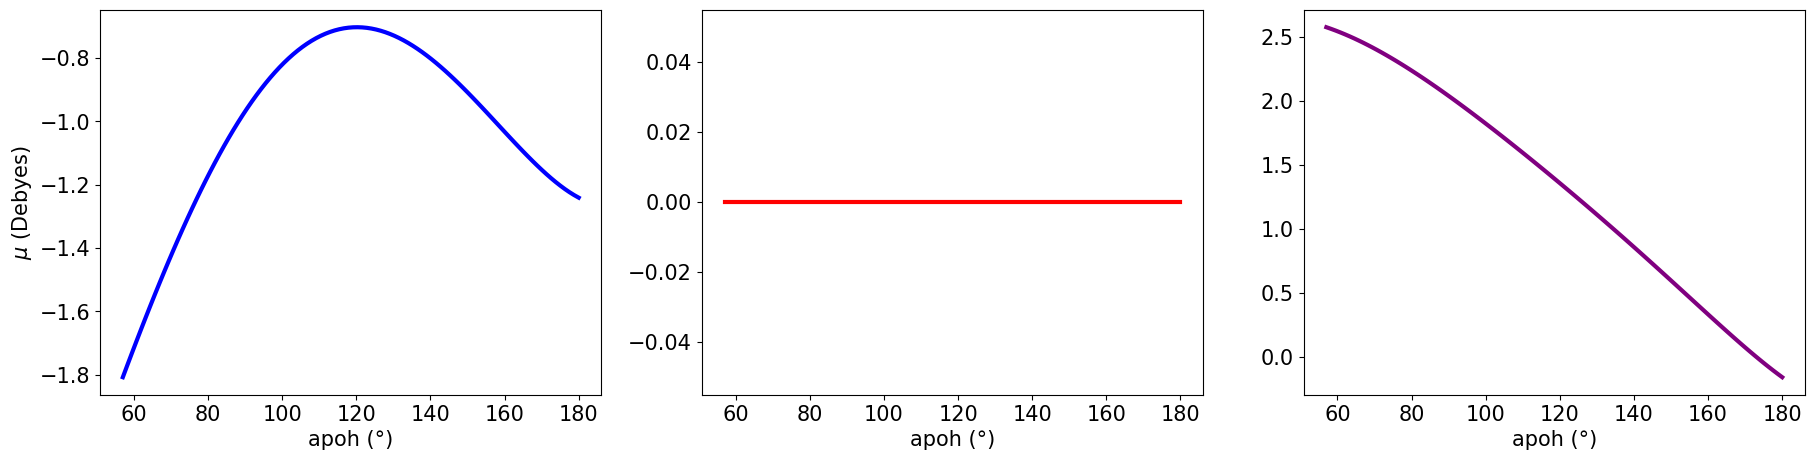

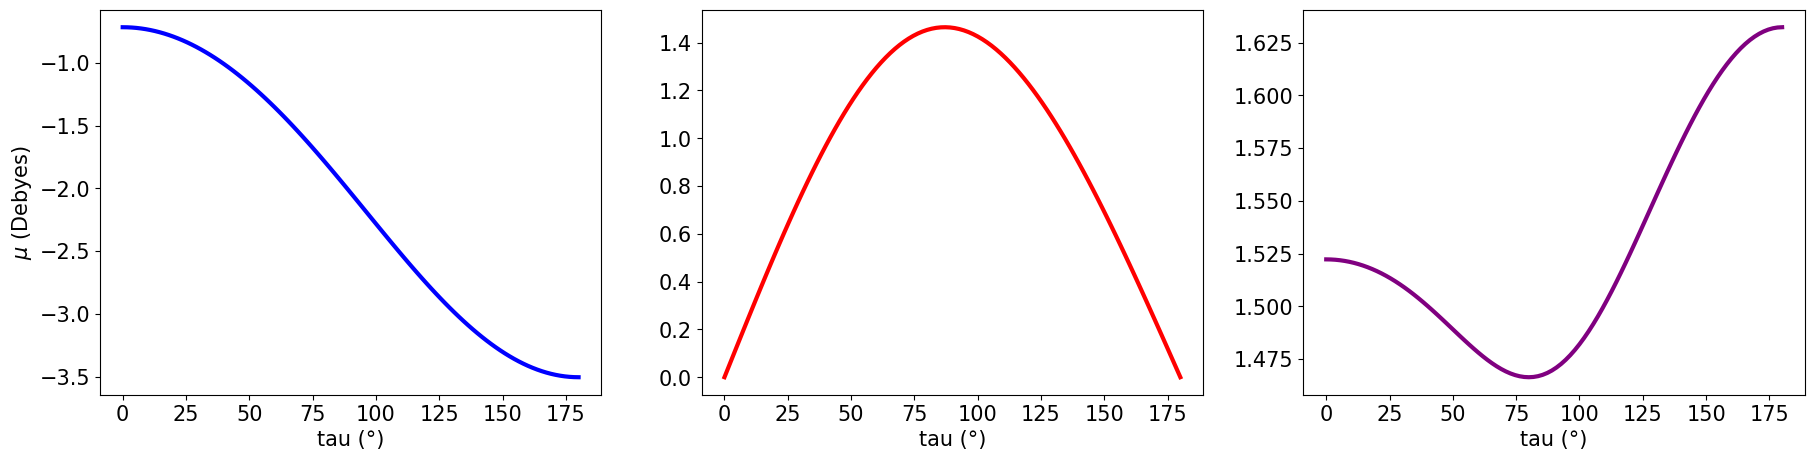

In [17]:
dms_6d = [x_dms, y_dms, z_dms]
sheets = ["rpo2", "rpo1", "roh", "aopo", "apoh", "tau"]
test_equilibriums = [1.60431, 1.46830, 0.96802, 110.730, 113.054, 0]
coordinate_lower_bounds = [1.3, 1.22,  0.77, 77, 57, 0] #rpo1 and rpo2 are swapped 
coordinate_upper_bounds = [2.4, 2.0, 1.5, 180, 180, 180]
coord_idx = [1,0,2,3,4,5] #to plot reversed coordinates correctly

for j in coord_idx:
    test_geometry = np.zeros((100, 6))
    for i in range(6):
        test_geometry[:, i] = test_equilibriums[i]
    test_geometry[:, j] = np.linspace(coordinate_lower_bounds[j],
                                      coordinate_upper_bounds[j],
                                      100)

    #plot each component for each coordinate
    fig, ax = plt.subplots(1,3, figsize=(22,5))
    for k in range(3):
        
        ax[k].plot(test_geometry[:, j], 
                   dms_6d[k](test_geometry), 
                   lw=3, 
                   color=line_color[k])
        
        ax[k].set_xlabel(f'{sheets[j]} ({x_units[j]})', fontsize=15)
        ax[k].tick_params(labelsize=15)
        if k == 0:
            ax[k].set_ylabel(f'$μ$ (Debyes)', fontsize=15)
        if j == 0:
            ax[k].set_title(titles[k], fontsize=20)    

The 6D fitted function reproduces the computed coordinate transformed dipole moments well. We conclude that the fitting of the DMS has been done correctly.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


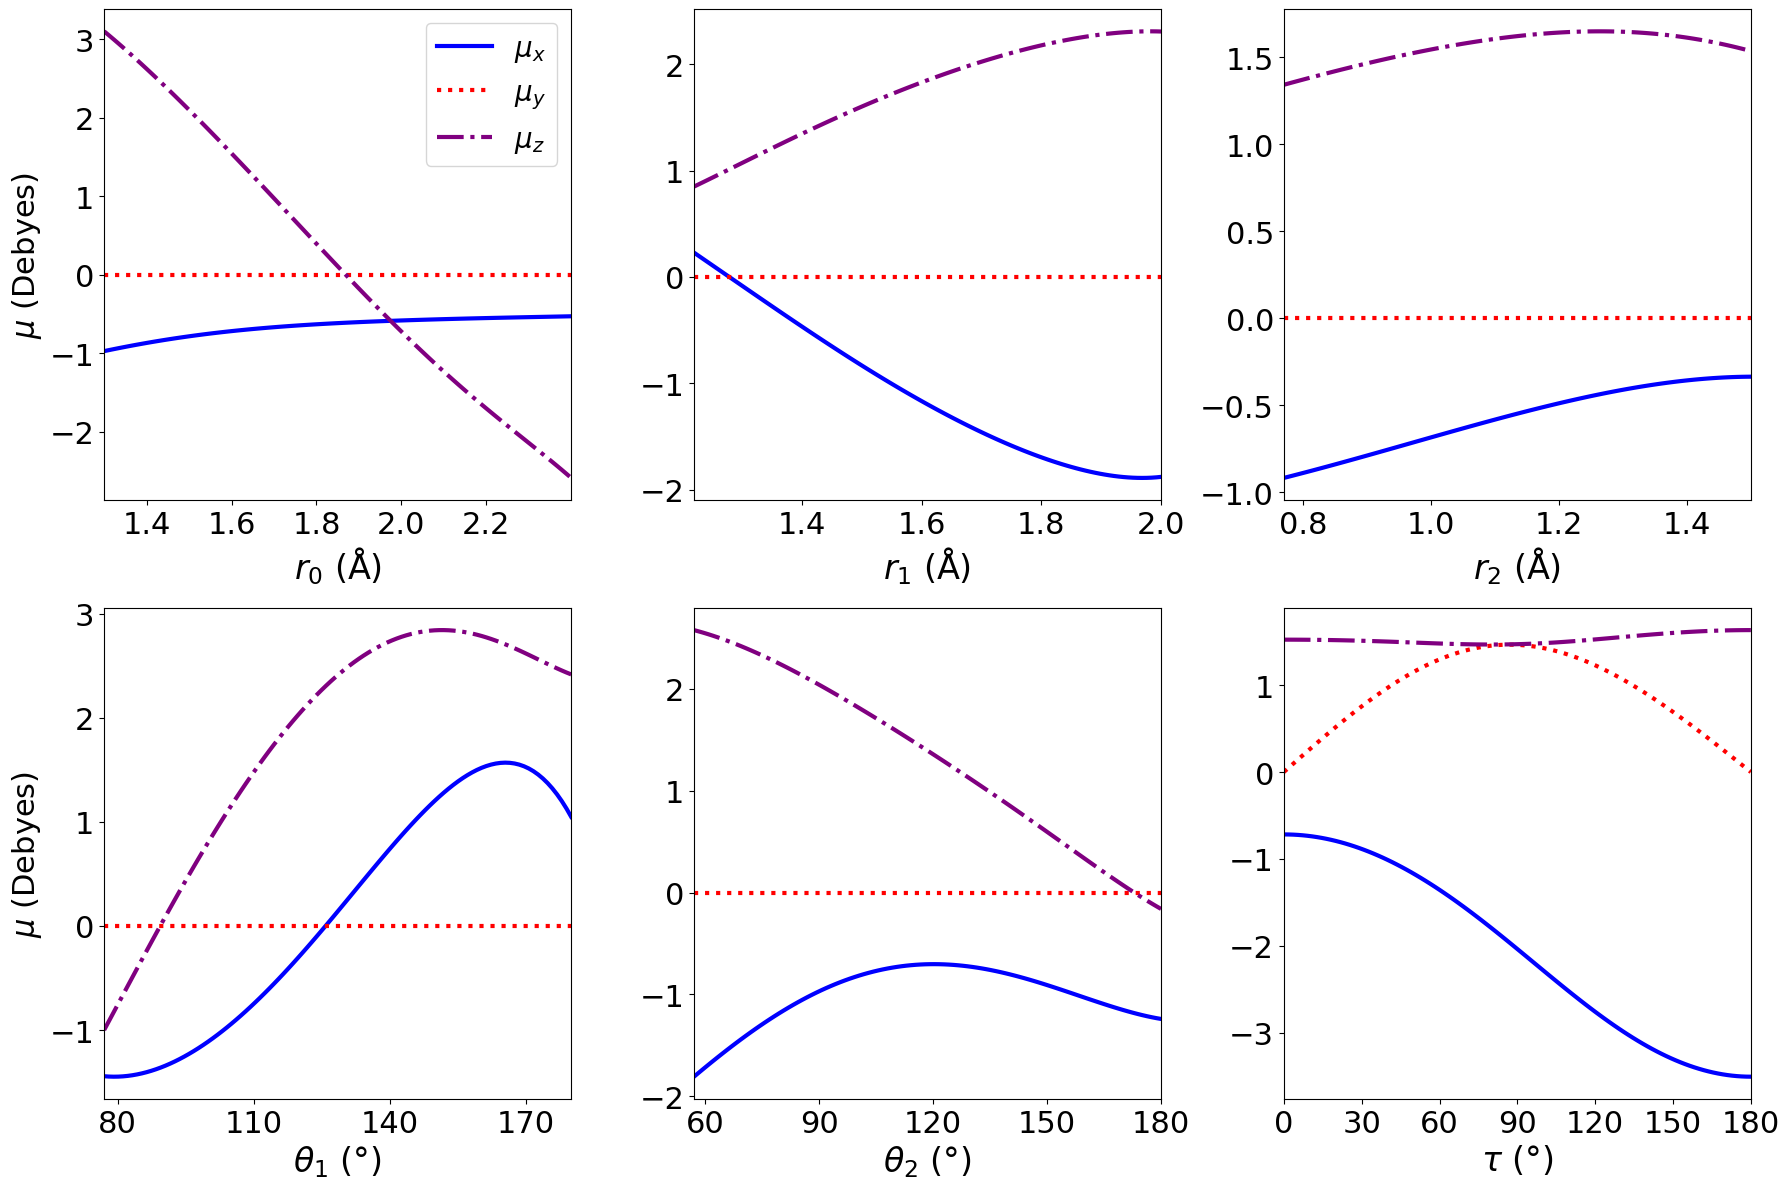

In [20]:
dms_6d = [x_dms, y_dms, z_dms]
sheets = ["rpo2", "rpo1", "roh", "aopo", "apoh", "tau"]
xlabels = [r'$r_0$',r'$r_1$',r'$r_2$', r'$\theta_1$', r'$\theta_2$', r'$\tau$']
test_equilibriums = [1.60431, 1.46830, 0.96802, 110.730, 113.054, 0]
coordinate_lower_bounds = [1.3, 1.22,  0.77, 77, 57, 0]
coordinate_upper_bounds = [2.4, 2.0, 1.5, 180, 180, 180]
coord_idx = [0, 1, 2, 3, 4, 5]
labels = [f'$μ_x$',f'$μ_y$', f'$μ_z$']

line_styles = ['-', ':', '-.']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for plot_num, j in enumerate(coord_idx):
    ax = axes[plot_num // 3, plot_num % 3]

    test_geometry = np.zeros((100, 6))
    for i in range(6):
        test_geometry[:, i] = test_equilibriums[i]
    test_geometry[:, j] = np.linspace(coordinate_lower_bounds[j],
                                      coordinate_upper_bounds[j],
                                      100)

    for k in range(3):
        ax.plot(test_geometry[:, j],
                dms_6d[k](test_geometry),
                lw=3,
                color=line_color[k],
                linestyle=line_styles[k],
                label=labels[k])

    ax.set_xlabel(f'{xlabels[j]} ({x_units[j]})', fontsize=24)
    ax.set_xlim(coordinate_lower_bounds[j],
                coordinate_upper_bounds[j],)
    if plot_num % 3 == 0:
        ax.set_ylabel(f'$μ$ (Debyes)', fontsize=22)
    ax.tick_params(labelsize=22)
    #ax.set_title(sheets[j], fontsize=20)

axes[0, 0].set_xticks(np.arange(1.4, 2.40, 0.2))
axes[1, 0].set_xticks(range(80, 181, 30))
axes[1, 1].set_xticks(range(60, 181, 30))
axes[1, 2].set_xticks(range(0, 181, 30))

axes[0, 0].legend(fontsize=20)
plt.tight_layout()
#plt.savefig(fname='1d_cuts_dmsfit', orientation='Landscape',  transparent=False, pad_inches=0)
plt.savefig(fname='1d_cuts_dmsfit.eps', 
            format='eps', 
            orientation='Portrait',  
            transparent=False, 
            bbox_inches="tight",
            pad_inches=0)
plt.show()